#**PC Build Price Prediction**

In [416]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# **1. Loading the Dataset**

In [417]:
df = pd.read_csv(r'/content/billing_data.csv')

# **2. E-D-A**

##### **1. Shape of the data**

In [418]:

# Finding the Shape of the Dataset
df.shape

(20000, 39)

In [419]:
# top 5 rows with columns
df.head()

,BuildID,Motherboard_Brand,Motherboard_Model,Motherboard_Chipset,CPU_Brand,CPU_Model,CPU_Cores,CPU_Threads,RAM_Brand,RAM_Size_GB,...,Component_Price_PSU,Component_Price_Storage,Assembly_Fee,Build_Price_INR,Build_Notes,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Billing_Type
0,BUILD-00001,EVGA,EVGA-A520-Model350,A520,AMD,AMD Ryzen 9 7950X,16,32,G.Skill,8,...,6289,12000,10476,126425,Topology concurrency bandwidth driver driver l...,NaN,NaN,NaN,NaN,Cash on Delivery
1,BUILD-00002,Intel,Intel-B650-Model814,B650,AMD,AMD Ryzen 9 7950X,16,32,Crucial,16,...,14121,6000,12691,240660,Sustained benchmark concurrency frequency opti...,NaN,NaN,NaN,NaN,Debit Card
2,BUILD-00003,Intel,Intel-B660-Model691,B660,Intel,Intel Pentium Gold G7400,2,4,G.Skill,16,...,8326,1800,8697,103795,Sockets stable bios concurrency throughput lat...,NaN,NaN,NaN,NaN,UPI
3,BUILD-00004,MSI,MSI-H670-Model488,H670,Intel,Intel Core i7-13700K,16,24,Kingston,64,...,19110,9000,40059,408867,Benchmark firmware bios thermal vrm bandwidth ...,NaN,NaN,NaN,NaN,UPI
4,BUILD-00005,Gigabyte,Gigabyte-B650-Model352,B650,AMD,AMD Ryzen 7 7700X,8,16,Patriot,16,...,3607,9000,9222,109276,Latency benchmark performance topology stable ...,NaN,NaN,NaN,NaN,UPI


In [420]:
df.columns

Index(['BuildID', 'Motherboard_Brand', 'Motherboard_Model',
       'Motherboard_Chipset', 'CPU_Brand', 'CPU_Model', 'CPU_Cores',
       'CPU_Threads', 'RAM_Brand', 'RAM_Size_GB', 'RAM_Type', 'RAM_Speed_MHz',
       'GPU_Brand', 'GPU_Model', 'GPU_Tier', 'Cooler_Brand', 'Cooler_Type',
       'Cabinet_Brand', 'Cabinet_Type', 'PSU_Brand', 'PSU_Wattage',
       'Storage_Type', 'Storage_Capacity_GB', 'Component_Price_CPU',
       'Component_Price_Motherboard', 'Component_Price_RAM',
       'Component_Price_GPU', 'Component_Price_Cooler',
       'Component_Price_Cabinet', 'Component_Price_PSU',
       'Component_Price_Storage', 'Assembly_Fee', 'Build_Price_INR',
       'Build_Notes', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36',
       'Unnamed: 37', 'Billing_Type'],
      dtype='object')

##### **2. Droping the unwanted columns**

In [421]:
# Droping the unwanted columns i.e(Unnamed: 35,36,37 , )
df = df.drop(columns=['Billing_Type','Unnamed: 36','Unnamed: 37',
                      'Unnamed: 35','Unnamed: 34','Build_Notes',
                      'Motherboard_Model','BuildID'])


##### **3. Subtracting Assembly_Fee with Build_Price**

In [422]:
# Subtracting the Assembly_Fee from the Build_price_INR
df['Build_Price_INR'] = df['Build_Price_INR']-df['Assembly_Fee']

In [423]:
# There is no use of the Assembly_Fee column so it is better to drop this column
df = df.drop('Assembly_Fee',axis=1)

In [424]:
df.head(10)

,Motherboard_Brand,Motherboard_Chipset,CPU_Brand,CPU_Model,CPU_Cores,CPU_Threads,RAM_Brand,RAM_Size_GB,RAM_Type,RAM_Speed_MHz,...,Storage_Capacity_GB,Component_Price_CPU,Component_Price_Motherboard,Component_Price_RAM,Component_Price_GPU,Component_Price_Cooler,Component_Price_Cabinet,Component_Price_PSU,Component_Price_Storage,Build_Price_INR
0,EVGA,A520,AMD,AMD Ryzen 9 7950X,16,32,G.Skill,8,DDR4,4000,...,2000,70000,6300,3456,9008,2634,5122,6289,12000,115949
1,Intel,B650,AMD,AMD Ryzen 9 7950X,16,32,Crucial,16,DDR4,2666,...,2000,70000,14000,5888,108543,3312,6737,14121,6000,227969
2,Intel,B660,Intel,Intel Pentium Gold G7400,2,4,G.Skill,16,DDR4,4000,...,256,4500,9000,6912,44658,13496,5190,8326,1800,95098
3,MSI,H670,Intel,Intel Core i7-13700K,16,24,Kingston,64,DDR4,4000,...,2000,42000,11000,24320,233742,8247,10487,19110,9000,368808
4,Gigabyte,B650,AMD,AMD Ryzen 7 7700X,8,16,Patriot,16,DDR5,5600,...,2000,45000,15120,12528,9758,0,5511,3607,9000,100054
5,ASRock,H610,Intel,Intel Pentium Gold G7400,2,4,ADATA,32,DDR5,3200,...,512,4500,5700,25344,10602,2814,3605,5659,4000,61933
6,Intel,H610,Intel,Intel Core i5-13600K,14,20,G.Skill,8,DDR4,3600,...,2000,28000,6000,3456,11004,2567,5374,3875,12000,74558
7,Intel,B650,AMD,AMD Athlon 3000G,2,4,Patriot,16,DDR4,3000,...,2000,3500,14000,5568,9815,15072,9766,4661,12000,75523
8,ASUS,H610,Intel,Intel Core i5-13600K,14,20,G.Skill,16,DDR4,2400,...,2000,28000,6720,6912,233736,12197,6405,9117,6000,306185
9,MSI,Z790,Intel,Intel Core i3-13100,4,8,Patriot,16,DDR5,5200,...,1000,8500,24200,12528,260401,2912,4497,9876,7000,333493


##### **4. Cleaning Data Noise**

In [425]:
# There is a '0' in the cComponent_Price_Cooler
# Now this problem should be shorted out
# Replacing the all the 0 with np.nan values
df['Component_Price_Motherboard'] = df['Component_Price_Motherboard'].replace(0,np.nan)
df['Component_Price_RAM'] = df['Component_Price_RAM'].replace(0,np.nan)
df['Component_Price_GPU'] = df['Component_Price_GPU'].replace(0,np.nan)
df['Component_Price_CPU'] = df['Component_Price_CPU'].replace(0,np.nan)
df['Component_Price_Cooler'] = df['Component_Price_Cooler'].replace(0,np.nan)
df['Component_Price_Cabinet'] = df['Component_Price_Cabinet'].replace(0,np.nan)
df['Component_Price_PSU'] = df['Component_Price_PSU'].replace(0,np.nan)
df['Component_Price_Storage'] = df['Component_Price_Storage'].replace(0,np.nan)
df['Build_Price_INR'] = df['Build_Price_INR'].replace(0,np.nan)

In [426]:
# This will convertes all the data to the lowercase
for i in df.select_dtypes(include = 'object').columns:
  df[i] = df[i].str.lower()

In [427]:
# This will removes the white spaces and replaces with Underscore(_)
for i in df.select_dtypes(include='object').columns:
    df[i] = df[i].str.strip().str.replace(' ', '_')

In [428]:
# This will removes the '.' spaces and replaces with Underscore(_)
for i in df.select_dtypes(include='object').columns:
    df[i] = df[i].str.strip().str.replace('.', '_')

In [429]:
# converting the columns to the lowercase
df.columns = df.columns.str.lower()

In [430]:
# renameing the columns names
df = df.rename(columns = {'component_price_psu':'psu_price'})
df = df.rename(columns = {'component_price_motherboard':'motherboard_price'})
df = df.rename(columns = {'component_price_gpu':'gpu_price'})
df = df.rename(columns = {'component_price_cpu':'cpu_price'})
df = df.rename(columns = {'component_price_cooler':'cooler_price'})
df = df.rename(columns = {'component_price_cabinet':'cabnit_price'})
df = df.rename(columns = {'component_price_storage':'storage_price'})
df = df.rename(columns = {'build_price_inr':'total_price'})
df = df.rename(columns = {'component_price_ram':'ram_price'})
df = df.rename(columns = {'Component_Price_Cooler':'price_price'})

In [431]:
df.head()

,motherboard_brand,motherboard_chipset,cpu_brand,cpu_model,cpu_cores,cpu_threads,ram_brand,ram_size_gb,ram_type,ram_speed_mhz,...,storage_capacity_gb,cpu_price,motherboard_price,ram_price,gpu_price,cooler_price,cabnit_price,psu_price,storage_price,total_price
0,evga,a520,amd,amd_ryzen_9_7950x,16,32,g_skill,8,ddr4,4000,...,2000,70000,6300,3456,9008,2634.0,5122,6289,12000,115949
1,intel,b650,amd,amd_ryzen_9_7950x,16,32,crucial,16,ddr4,2666,...,2000,70000,14000,5888,108543,3312.0,6737,14121,6000,227969
2,intel,b660,intel,intel_pentium_gold_g7400,2,4,g_skill,16,ddr4,4000,...,256,4500,9000,6912,44658,13496.0,5190,8326,1800,95098
3,msi,h670,intel,intel_core_i7-13700k,16,24,kingston,64,ddr4,4000,...,2000,42000,11000,24320,233742,8247.0,10487,19110,9000,368808
4,gigabyte,b650,amd,amd_ryzen_7_7700x,8,16,patriot,16,ddr5,5600,...,2000,45000,15120,12528,9758,NaN,5511,3607,9000,100054


##### **5. Filling the Missing Values**

In [432]:
# There are some mising values in the Component_Price_Cooler columns with 5%
# The missing values can be filled by the Mean
#df['cooler_price'] = df['cooler_price'].fillna(df['cooler_price'].mean())

In [433]:
# After filling the missing values
df.isnull().sum()/len(df)*100

,0
motherboard_brand,0.000
motherboard_chipset,0.000
cpu_brand,0.000
cpu_model,0.000
cpu_cores,0.000
cpu_threads,0.000
ram_brand,0.000
ram_size_gb,0.000
ram_type,0.000
ram_speed_mhz,0.000


##### **6. Droping Duplicated Values**

In [434]:
# Checking wheather the dataset is having duplicated values
df.duplicated().sum()

np.int64(10000)

In [435]:
# There are total 10000 duplicated values are present in the data
# So, Droping the duplicated values
df = df.drop_duplicates()

In [436]:
# After removing the duplicates checking the data
df.duplicated().sum()

np.int64(0)

In [437]:
# After removing the missing values and duplicated Values this is the shape of the dataset
df.shape
# This is the final dataset Shape of the dataset

(10000, 30)

##### **7. Value_counts and nunique**

In [438]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 9999
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   motherboard_brand    10000 non-null  object 
 1   motherboard_chipset  10000 non-null  object 
 2   cpu_brand            10000 non-null  object 
 3   cpu_model            10000 non-null  object 
 4   cpu_cores            10000 non-null  int64  
 5   cpu_threads          10000 non-null  int64  
 6   ram_brand            10000 non-null  object 
 7   ram_size_gb          10000 non-null  int64  
 8   ram_type             10000 non-null  object 
 9   ram_speed_mhz        10000 non-null  int64  
 10  gpu_brand            10000 non-null  object 
 11  gpu_model            10000 non-null  object 
 12  gpu_tier             10000 non-null  object 
 13  cooler_brand         10000 non-null  object 
 14  cooler_type          10000 non-null  object 
 15  cabinet_brand        10000 non-null  objec

In [439]:
num_col = df.select_dtypes(include = ['int64','float64']).columns

In [440]:
for i in num_col:
    print('Value counts:\n', df[i].value_counts())
    print('--------------------------------------------------------------------------')
    print('Unique counts:\n', df[i].unique())
    print('\n')
    #print('nunique',df[i].nunique())


Value counts:
 cpu_cores
6     2081
2     1982
16    1965
4     1029
14    1021
8      970
24     952
Name: count, dtype: int64
--------------------------------------------------------------------------
Unique counts:
 [16  2  8 14  4 24  6]


Value counts:
 cpu_threads
12    2081
4     1982
32    1927
8     1029
20    1021
24     990
16     970
Name: count, dtype: int64
--------------------------------------------------------------------------
Unique counts:
 [32  4 24 16 20  8 12]


Value counts:
 ram_size_gb
16     4952
8      3062
32     1486
64      400
128     100
Name: count, dtype: int64
--------------------------------------------------------------------------
Unique counts:
 [  8  16  64  32 128]


Value counts:
 ram_speed_mhz
3600    1896
3200    1865
4800    1161
5200    1091
5600    1086
2666     752
4000     749
2400     733
3000     667
Name: count, dtype: int64
--------------------------------------------------------------------------
Unique counts:
 [4000 2666 5600 320

##### **8. Converting to int to object**

In [441]:
# ----- CPU CORES -----
df['cpu_cores'] = df['cpu_cores'].astype(str).str.replace('_core','') + '_core'
df['cpu_cores'] = df['cpu_cores'].astype('object')

# ----- CPU THREADS -----
df['cpu_threads'] = df['cpu_threads'].astype(str).str.replace('_threads','') + '_threads'
df['cpu_threads'] = df['cpu_threads'].astype('object')

# ----- PSU WATTAGE -----
df['psu_wattage'] = df['psu_wattage'].astype(str).str.replace('_wattage','') + '_wattage'
df['psu_wattage'] = df['psu_wattage'].astype('object')

# ----- RAM SPEED (MHZ) -----
df['ram_speed_mhz'] = df['ram_speed_mhz'].astype(str).str.replace('_mhz','') + '_mhz'
df['ram_speed_mhz'] = df['ram_speed_mhz'].astype('object')

# ----- RAM SIZE (GB) -----
df['ram_size_gb'] = df['ram_size_gb'].astype(str).str.replace('_gb','') + '_gb'
df['ram_size_gb'] = df['ram_size_gb'].astype('object')

# ----- STORAGE CAPACITY (GB) -----
df['storage_capacity_gb'] = df['storage_capacity_gb'].astype(str).str.replace('_gb','') + '_gb'
df['storage_capacity_gb'] = df['storage_capacity_gb'].astype('object')

In [442]:
df.head()

,motherboard_brand,motherboard_chipset,cpu_brand,cpu_model,cpu_cores,cpu_threads,ram_brand,ram_size_gb,ram_type,ram_speed_mhz,...,storage_capacity_gb,cpu_price,motherboard_price,ram_price,gpu_price,cooler_price,cabnit_price,psu_price,storage_price,total_price
0,evga,a520,amd,amd_ryzen_9_7950x,16_core,32_threads,g_skill,8_gb,ddr4,4000_mhz,...,2000_gb,70000,6300,3456,9008,2634.0,5122,6289,12000,115949
1,intel,b650,amd,amd_ryzen_9_7950x,16_core,32_threads,crucial,16_gb,ddr4,2666_mhz,...,2000_gb,70000,14000,5888,108543,3312.0,6737,14121,6000,227969
2,intel,b660,intel,intel_pentium_gold_g7400,2_core,4_threads,g_skill,16_gb,ddr4,4000_mhz,...,256_gb,4500,9000,6912,44658,13496.0,5190,8326,1800,95098
3,msi,h670,intel,intel_core_i7-13700k,16_core,24_threads,kingston,64_gb,ddr4,4000_mhz,...,2000_gb,42000,11000,24320,233742,8247.0,10487,19110,9000,368808
4,gigabyte,b650,amd,amd_ryzen_7_7700x,8_core,16_threads,patriot,16_gb,ddr5,5600_mhz,...,2000_gb,45000,15120,12528,9758,NaN,5511,3607,9000,100054


##### **9. Outliers in the data**

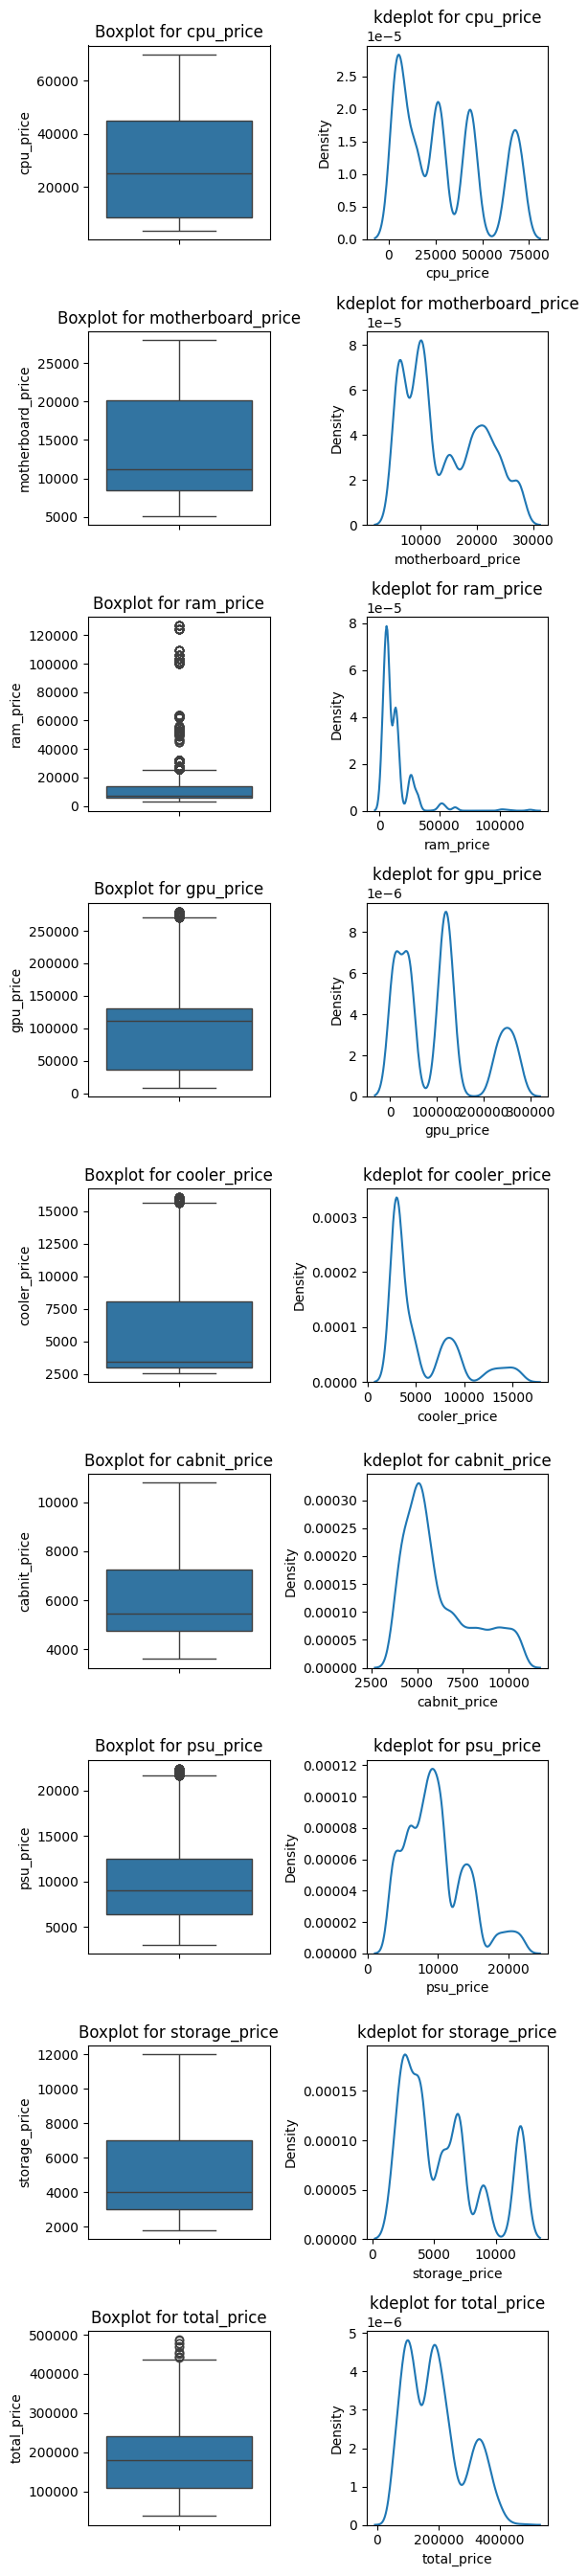

In [443]:
num_col = df.select_dtypes(include = ['int64','float64']).columns
l = len(num_col)
plt.figure(figsize=(6,l*3))
for i ,col in enumerate(num_col,1):
  # Boxplot
  plt.subplot(l,2,2*i-1)
  sns.boxplot(y=df[col])
  plt.title(f'Boxplot for {col}')
  plt.tight_layout()
  # kdeplot
  plt.subplot(l,2,2*i)
  sns.kdeplot(df[col])
  plt.title(f'kdeplot for {col}')
  plt.tight_layout()
plt.show()

In [444]:

Q1 = df['total_price'].quantile(0.5)
Q3 = df['total_price'].quantile(0.74)
IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR
df['total_price'] = df['total_price'].clip(upper=upper_limit)


In [445]:
# log normal
#df['total_price'] = np.log1p(df['total_price'])


In [446]:
df['total_price'].head()

,total_price
0,115949.0
1,227969.0
2,95098.0
3,326180.7
4,100054.0


##### **10. Features selection**

In [447]:
num_col = df.select_dtypes(include = ['int64','float64'])
num_col.head()

,cpu_price,motherboard_price,ram_price,gpu_price,cooler_price,cabnit_price,psu_price,storage_price,total_price
0,70000,6300,3456,9008,2634.0,5122,6289,12000,115949.0
1,70000,14000,5888,108543,3312.0,6737,14121,6000,227969.0
2,4500,9000,6912,44658,13496.0,5190,8326,1800,95098.0
3,42000,11000,24320,233742,8247.0,10487,19110,9000,326180.7
4,45000,15120,12528,9758,NaN,5511,3607,9000,100054.0


In [448]:
corr_data = num_col.corr()['total_price'].sort_values(ascending=False)

In [449]:
print(corr_data)

total_price          1.000000
gpu_price            0.949314
psu_price            0.743407
cpu_price            0.234164
ram_price            0.147494
motherboard_price    0.068478
cabnit_price         0.039773
storage_price        0.039274
cooler_price         0.019003
Name: total_price, dtype: float64


In [450]:
corr_data = pd.DataFrame(corr_data).reset_index()

In [451]:
corr_data

,index,total_price
0,total_price,1.000000
1,gpu_price,0.949314
2,psu_price,0.743407
3,cpu_price,0.234164
4,ram_price,0.147494
5,motherboard_price,0.068478
6,cabnit_price,0.039773
7,storage_price,0.039274
8,cooler_price,0.019003


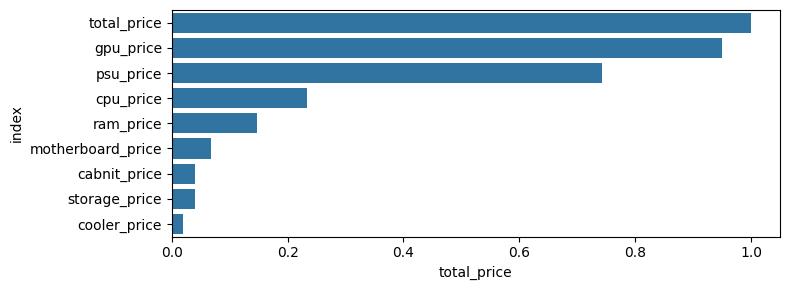

In [452]:
# Advanced feature selection
plt.figure(figsize=(8,3))
sns.barplot(data = corr_data,y='index',x='total_price')
plt.tight_layout()
plt.show()

These have weak correlation, meaning they add very little predictive power:

* RAM Price (0.16)

* Motherboard Price (0.07)

* Cabinet Price (0.04)

* Storage Price (0.04)

* Cooler Price (0.02)

* And all the numerical features

* Because taking the price from the user it dosent make senes

* so droping the all the numerical values

In [453]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 9999
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   motherboard_brand    10000 non-null  object 
 1   motherboard_chipset  10000 non-null  object 
 2   cpu_brand            10000 non-null  object 
 3   cpu_model            10000 non-null  object 
 4   cpu_cores            10000 non-null  object 
 5   cpu_threads          10000 non-null  object 
 6   ram_brand            10000 non-null  object 
 7   ram_size_gb          10000 non-null  object 
 8   ram_type             10000 non-null  object 
 9   ram_speed_mhz        10000 non-null  object 
 10  gpu_brand            10000 non-null  object 
 11  gpu_model            10000 non-null  object 
 12  gpu_tier             10000 non-null  object 
 13  cooler_brand         10000 non-null  object 
 14  cooler_type          10000 non-null  object 
 15  cabinet_brand        10000 non-null  objec

In [454]:
# Droping the above features
df = df.drop(columns = ['ram_price','motherboard_price','cabnit_price','storage_price','cooler_price','cpu_price','gpu_price','psu_price'])

In [455]:
# Feature selection for Categorical data
cat_col = df.select_dtypes(include = 'object')
cat_col.head()

,motherboard_brand,motherboard_chipset,cpu_brand,cpu_model,cpu_cores,cpu_threads,ram_brand,ram_size_gb,ram_type,ram_speed_mhz,...,gpu_model,gpu_tier,cooler_brand,cooler_type,cabinet_brand,cabinet_type,psu_brand,psu_wattage,storage_type,storage_capacity_gb
0,evga,a520,amd,amd_ryzen_9_7950x,16_core,32_threads,g_skill,8_gb,ddr4,4000_mhz,...,gtx_1650,entry,deepcool,air,corsair,mid_tower,corsair_(budget),650_wattage,ssd_nvme,2000_gb
1,intel,b650,amd,amd_ryzen_9_7950x,16_core,32_threads,crucial,16_gb,ddr4,2666_mhz,...,rtx_4070,high,deepcool,air,thermaltake,mini-itx,cooler_master,1000_wattage,hdd,2000_gb
2,intel,b660,intel,intel_pentium_gold_g7400,2_core,4_threads,g_skill,16_gb,ddr4,4000_mhz,...,radeon_rx_7600,mid,cooler_master,aio_360mm,fractal_design,mini-itx,seasonic,750_wattage,ssd_sata,256_gb
3,msi,h670,intel,intel_core_i7-13700k,16_core,24_threads,kingston,64_gb,ddr4,4000_mhz,...,rtx_4090,ultra,noctua,aio_240mm,nzxt,full_tower,corsair_(budget),1200_wattage,ssd_sata,2000_gb
4,gigabyte,b650,amd,amd_ryzen_7_7700x,8_core,16_threads,patriot,16_gb,ddr5,5600_mhz,...,gtx_1650,entry,cooler_master,stock,fractal_design,mid_tower,seasonic,450_wattage,ssd_sata,2000_gb


In [456]:
df = df.drop(columns = ['gpu_tier','cpu_cores','cpu_threads'])

In [457]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   motherboard_brand    10000 non-null  object 
 1   motherboard_chipset  10000 non-null  object 
 2   cpu_brand            10000 non-null  object 
 3   cpu_model            10000 non-null  object 
 4   ram_brand            10000 non-null  object 
 5   ram_size_gb          10000 non-null  object 
 6   ram_type             10000 non-null  object 
 7   ram_speed_mhz        10000 non-null  object 
 8   gpu_brand            10000 non-null  object 
 9   gpu_model            10000 non-null  object 
 10  cooler_brand         10000 non-null  object 
 11  cooler_type          10000 non-null  object 
 12  cabinet_brand        10000 non-null  object 
 13  cabinet_type         10000 non-null  object 
 14  psu_brand            10000 non-null  object 
 15  psu_wattage          10000 non-null  objec

# **3. Model Building**

In [458]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   motherboard_brand    10000 non-null  object 
 1   motherboard_chipset  10000 non-null  object 
 2   cpu_brand            10000 non-null  object 
 3   cpu_model            10000 non-null  object 
 4   ram_brand            10000 non-null  object 
 5   ram_size_gb          10000 non-null  object 
 6   ram_type             10000 non-null  object 
 7   ram_speed_mhz        10000 non-null  object 
 8   gpu_brand            10000 non-null  object 
 9   gpu_model            10000 non-null  object 
 10  cooler_brand         10000 non-null  object 
 11  cooler_type          10000 non-null  object 
 12  cabinet_brand        10000 non-null  object 
 13  cabinet_type         10000 non-null  object 
 14  psu_brand            10000 non-null  object 
 15  psu_wattage          10000 non-null  objec

##### **1. Spliting the data into X and y(target_variable)**

In [459]:
y = df['total_price']
X = df.drop(columns = ['total_price','motherboard_chipset','cpu_brand'])

##### **2. Data Transformations**

In [460]:
from sklearn.model_selection import train_test_split

In [461]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [462]:
print(X_train.shape)
print(X_test.shape)

(8000, 16)
(2000, 16)


In [463]:
print(y_train.shape)
print(y_test.shape)

(8000,)
(2000,)


In [464]:
print(X_train.info())

<class 'pandas.core.frame.DataFrame'>
Index: 8000 entries, 9254 to 7270
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   motherboard_brand    8000 non-null   object
 1   cpu_model            8000 non-null   object
 2   ram_brand            8000 non-null   object
 3   ram_size_gb          8000 non-null   object
 4   ram_type             8000 non-null   object
 5   ram_speed_mhz        8000 non-null   object
 6   gpu_brand            8000 non-null   object
 7   gpu_model            8000 non-null   object
 8   cooler_brand         8000 non-null   object
 9   cooler_type          8000 non-null   object
 10  cabinet_brand        8000 non-null   object
 11  cabinet_type         8000 non-null   object
 12  psu_brand            8000 non-null   object
 13  psu_wattage          8000 non-null   object
 14  storage_type         8000 non-null   object
 15  storage_capacity_gb  8000 non-null   object
dtypes: objec

In [465]:
cat_col = df.select_dtypes(include = 'object').columns
cat_col

Index(['motherboard_brand', 'motherboard_chipset', 'cpu_brand', 'cpu_model',
       'ram_brand', 'ram_size_gb', 'ram_type', 'ram_speed_mhz', 'gpu_brand',
       'gpu_model', 'cooler_brand', 'cooler_type', 'cabinet_brand',
       'cabinet_type', 'psu_brand', 'psu_wattage', 'storage_type',
       'storage_capacity_gb'],
      dtype='object')

In [466]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8000 entries, 9254 to 7270
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   motherboard_brand    8000 non-null   object
 1   cpu_model            8000 non-null   object
 2   ram_brand            8000 non-null   object
 3   ram_size_gb          8000 non-null   object
 4   ram_type             8000 non-null   object
 5   ram_speed_mhz        8000 non-null   object
 6   gpu_brand            8000 non-null   object
 7   gpu_model            8000 non-null   object
 8   cooler_brand         8000 non-null   object
 9   cooler_type          8000 non-null   object
 10  cabinet_brand        8000 non-null   object
 11  cabinet_type         8000 non-null   object
 12  psu_brand            8000 non-null   object
 13  psu_wattage          8000 non-null   object
 14  storage_type         8000 non-null   object
 15  storage_capacity_gb  8000 non-null   object
dtypes: objec

In [467]:
from sklearn.preprocessing import OrdinalEncoder,MinMaxScaler,StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline


In [468]:
transformer = ColumnTransformer(
    transformers = [
        ('cat',OneHotEncoder(),[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15])
    ],remainder='passthrough')


In [469]:
#cat_features = list(range(X.shape[1]))


In [470]:
!pip install catboost

##### **3. Model Building**

In [471]:
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error,mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [472]:
# Implementing the pipeline
# Implementing the pipeline
lgbm = make_pipeline(transformer, LGBMRegressor())
rmf  = make_pipeline(transformer, RandomForestRegressor())
dt   = make_pipeline(transformer, DecisionTreeRegressor())
cat  = make_pipeline(transformer, CatBoostRegressor())
knn  = make_pipeline(transformer, KNeighborsRegressor())
xgb  = make_pipeline(transformer, XGBRegressor())


In [473]:
# Fitting lgbm
lgbm.fit(X_train,y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001061 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 186
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 93
[LightGBM] [Info] Start training from score 185481.027734


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat', OneHotEncoder(),
                                                  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9,
                                                   10, 11, 12, 13, 14, 15])])),
                ('lgbmregressor', LGBMRegressor())])

In [474]:
# Fitting random forest
rmf.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat', OneHotEncoder(),
                                                  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9,
                                                   10, 11, 12, 13, 14, 15])])),
                ('randomforestregressor', RandomForestRegressor())])

In [475]:
# # fitting decission ttree
dt.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat', OneHotEncoder(),
                                                  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9,
                                                   10, 11, 12, 13, 14, 15])])),
                ('decisiontreeregressor', DecisionTreeRegressor())])

In [476]:
# fitting cataboost
cat.fit(X_train,y_train)

Learning rate set to 0.056868
0:	learn: 81125.1773271	total: 4.7ms	remaining: 4.69s
1:	learn: 77427.6231386	total: 7.13ms	remaining: 3.56s
2:	learn: 73641.2700370	total: 9.33ms	remaining: 3.1s
3:	learn: 70246.5439378	total: 14ms	remaining: 3.49s
4:	learn: 67217.0790958	total: 19.7ms	remaining: 3.93s
5:	learn: 64584.8413268	total: 23.7ms	remaining: 3.92s
6:	learn: 61927.0978956	total: 27.3ms	remaining: 3.88s
7:	learn: 59097.9514149	total: 33.9ms	remaining: 4.21s
8:	learn: 56423.4572556	total: 40.7ms	remaining: 4.48s
9:	learn: 53938.7681581	total: 46.6ms	remaining: 4.61s
10:	learn: 51713.3124695	total: 53.2ms	remaining: 4.79s
11:	learn: 49618.4007588	total: 58.2ms	remaining: 4.79s
12:	learn: 47663.6121090	total: 64.8ms	remaining: 4.92s
13:	learn: 45692.4726654	total: 70.3ms	remaining: 4.95s
14:	learn: 43916.5784279	total: 75.8ms	remaining: 4.98s
15:	learn: 42397.1583790	total: 79.1ms	remaining: 4.87s
16:	learn: 41046.2240398	total: 82ms	remaining: 4.74s
17:	learn: 39623.3546610	total: 84

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat', OneHotEncoder(),
                                                  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9,
                                                   10, 11, 12, 13, 14, 15])])),
                ('catboostregressor',
                 <catboost.core.CatBoostRegressor object at 0x7c3da9e14e00>)])

In [477]:
# fitting the k-n-n
knn.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat', OneHotEncoder(),
                                                  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9,
                                                   10, 11, 12, 13, 14, 15])])),
                ('kneighborsregressor', KNeighborsRegressor())])

In [478]:
# fitting xgbm
xgb.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat', OneHotEncoder(),
                                                  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9,
                                                   10, 11, 12, 13, 14, 15])])),
                ('xgbregressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=None, device=None,
                              early_stopping_rounds=None,
                              enable_cate...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [479]:
# Predict from each model
lgbm_pred = lgbm.predict(X_test)
rmf_pred = rmf.predict(X_test)
dt_pred = dt.predict(X_test)
cat_pred = cat.predict(X_test)
knn_pred = knn.predict(X_test)
xgb_pred = xgb.predict(X_test)

In [480]:
# -------------------------------------
# Evaluation Function (COMPLETE VERSION)
# -------------------------------------

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

def evaluate(name, y_test, y_pred):
    """
    Prints MAE, MSE, RMSE, R², and sample residuals (actual - predicted)
    and returns the complete residual Series.

    Parameters:
        name (str): Model name
        y_test (Series or array): True target values
        y_pred (Series or array): Predicted target values

    Returns:
        residuals (Series): Actual - Predicted values for each test sample
    """

    print(f"\n{name} Results:")
    print("-" * 40)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2  = r2_score(y_test, y_pred)

    print(f"MAE  : {mae}")
    print(f"MSE  : {mse}")
    print(f"RMSE : {rmse}")
    print(f"R2   : {r2}")




In [481]:
evaluate("LGBM", y_test, lgbm_pred)
evaluate("RandomForest", y_test, rmf_pred)
evaluate("DecisionTree", y_test, dt_pred)
evaluate("CatBoost", y_test, cat_pred)
evaluate("KNN", y_test, knn_pred)
evaluate("XGBoost", y_test, xgb_pred)



LGBM Results:
----------------------------------------
MAE  : 8103.719192030179
MSE  : 111914042.02944031
RMSE : 10578.943332367384
R2   : 0.9853410433303029

RandomForest Results:
----------------------------------------
MAE  : 8909.897550000043
MSE  : 144057507.0770512
RMSE : 12002.395889031955
R2   : 0.9811307614675238

DecisionTree Results:
----------------------------------------
MAE  : 11377.347900000046
MSE  : 249354365.03103015
RMSE : 15790.95833162225
R2   : 0.9673385504972812

CatBoost Results:
----------------------------------------
MAE  : 8058.976526640857
MSE  : 103513618.25720361
RMSE : 10174.164253500314
R2   : 0.9864413650223022

KNN Results:
----------------------------------------
MAE  : 33401.71168000001
MSE  : 1892228691.3948267
RMSE : 43499.75507281422
R2   : 0.7521481853991331

XGBoost Results:
----------------------------------------
MAE  : 8803.072414062504
MSE  : 125931903.52387717
RMSE : 11221.938492251558
R2   : 0.9835049267847606


In [482]:
y.head()

,total_price
0,115949.0
1,227969.0
2,95098.0
3,326180.7
4,100054.0


In [483]:
#joblib.dump(xgb, r"C:\Users\yedee\Desktop\Deployment\xgb_model_pipeline.pkl")

In [484]:
import joblib

joblib.dump(xgb, "xgb_model_pipeline.pkl")

from google.colab import files
files.download("xgb_model_pipeline.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [485]:
from google.colab import files
df.to_csv("my_data.csv", index=False)
files.download("my_data.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>